# **Assignment 1: Demand prediction of bike sharing system**

Bike sharing services are nowadays spread all over the world. They are beneficial for cities as they offer a climate neutral and healthy way of transportation. Moreover, similar to e-scooters, for the companies and transportation researchers they generate valuable data. This includes the trip route, trip origins and destinations, duration, and much more.

In this assignment we use a public bike sharing dataset from Washington, D.C., USA. published by Fanaee-T, H. (2013). Bike Sharing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894.

## Your Task

Your task in this assignment is:

1) to predict the demand of hourly rentals (**target-column: cnt**) using the [XGBoost](https://xgboost.readthedocs.io/en/stable/) and linear regression model. In this notebook we have provided you with the basic structure how to approach the problem. Feel free to reuse and improve parts of the exercise material.

2) After you have created the model please upload your code to Github and post the link to the notebook in the corresponding forum for the assignment with a short text describing how you have solved the task.

## Load data

You can also find more information about the data and the columns at: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

In [3]:
import pandas as pd

#url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_2_regression_model/Exercise2BikeSharing.csv'
#df = pd.read_csv(url)

df = pd.read_csv('Exercise2BikeSharing.csv')
df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [7]:
df.shape


Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## Train / Test split
- Target: `cnt` (count of total rental bikes including both casual and registered)
- Predictors: weather (`temp`, `atemp`, `hum`, `windspeed`, `weathersit`), calendar (`hr`, `weekday`, `workingday`, `holiday`, `season`), and `yr`.
- We keep it simple; you can expand features (e.g., interactions) later.

In [8]:
from sklearn.model_selection import train_test_split
target = 'cnt'

X = df.copy()
y = df[target].astype(float)

# Remove some columns to avoid data leakage
X.drop(columns=[target, 'casual', 'registered', 'instant', 'dteday'], inplace=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)
print(X.columns.tolist())

(13903, 12) (3476, 12)
['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']


## Data Processing / Feature Engineering

Before training the model think about data processing and feature engineering steps if applicable, such as:
- adding/removal of features
- normalization
- one hot encoding
- ...


In [9]:
# Categorical columns that need one-hot encoding (no natural numeric order)
categorical_cols = ['season', 'mnth', 'hr', 'weekday', 'weathersit']

# Numerical columns to standardize
numerical_cols = ['temp', 'atemp', 'hum', 'windspeed']

# --- Version for Linear Regression: one-hot encoded + scaled ---
from sklearn.preprocessing import StandardScaler

X_train_lin = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_lin = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# align columns in case test set is missing a category that train has
X_test_lin = X_test_lin.reindex(columns=X_train_lin.columns, fill_value=0)

scaler = StandardScaler()
X_train_lin[numerical_cols] = scaler.fit_transform(X_train_lin[numerical_cols])
X_test_lin[numerical_cols] = scaler.transform(X_test_lin[numerical_cols])

# --- Version for XGBoost: raw features, no encoding/scaling needed ---
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

print("Linear regression feature shape:", X_train_lin.shape)
print("XGBoost feature shape:", X_train_xgb.shape)

Linear regression feature shape: (13903, 53)
XGBoost feature shape: (13903, 12)


## Hyperparameter optimization
Hyperparameter tuning helps find the best set of hyperparameters for your model. Use Grid Search or Random Search with Cross Validation from scikit-learn to search for the best combination of parameters.

In [10]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

param_distributions = {
    'n_estimators': [200, 300, 400, 600, 800],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
}

xgb_base = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=40,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_xgb, y_train)

print("Best parameters:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best parameters: {'subsample': 0.6, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV RMSE: 38.94021748832813


## Train the XGBoost and Linear regression models
Now, create an XGBoost and linear regression model using the best parameters and train them using the training data.

In [11]:
from sklearn.linear_model import LinearRegression

# XGBoost with best found parameters
best_xgb = search.best_estimator_  # already fitted on X_train_xgb during search.fit()

# Linear Regression
lin_model = LinearRegression()
lin_model.fit(X_train_lin, y_train)

LinearRegression()

## Make predictions
Use the trained models to make predictions on the test data and compare the performance of the XGBoost and linear regression models using metrics like Mean Squared Error (MSE) and R-squared.

In [12]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred_xgb = best_xgb.predict(X_test_xgb)
y_pred_lin = lin_model.predict(X_test_lin)

# rentals can't be negative, so clip
y_pred_xgb = np.clip(y_pred_xgb, 0, None)
y_pred_lin = np.clip(y_pred_lin, 0, None)

# Metrics
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

mse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print(f"XGBoost   -> MSE: {mse_xgb:.2f}, RMSE: {np.sqrt(mse_xgb):.2f}, R2: {r2_xgb:.4f}")
print(f"Linear Reg -> MSE: {mse_lin:.2f}, RMSE: {np.sqrt(mse_lin):.2f}, R2: {r2_lin:.4f}")

XGBoost   -> MSE: 1378.50, RMSE: 37.13, R2: 0.9565
Linear Reg -> MSE: 9555.55, RMSE: 97.75, R2: 0.6982


## Visualize the predictions and compare the mdoels
Create a "Actual vs. Predicted Values" graph to give a visual inspection of the prediction quality.

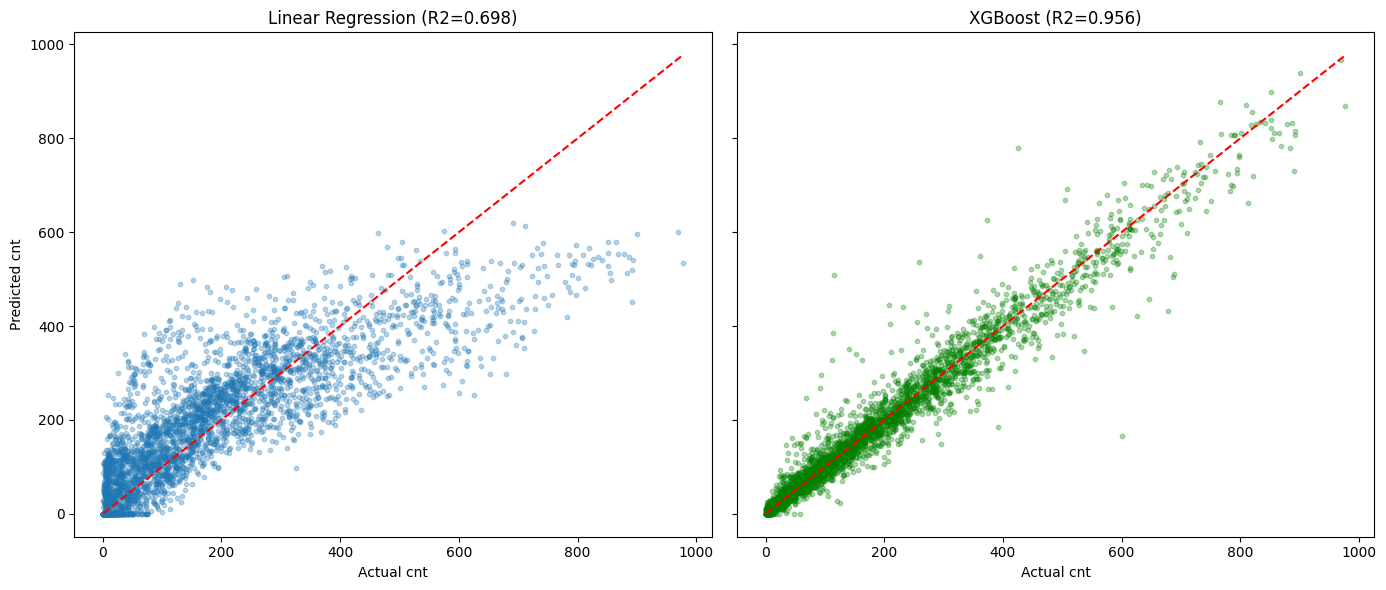

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

axes[0].scatter(y_test, y_pred_lin, alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title(f"Linear Regression (R2={r2_lin:.3f})")
axes[0].set_xlabel("Actual cnt")
axes[0].set_ylabel("Predicted cnt")

axes[1].scatter(y_test, y_pred_xgb, alpha=0.3, s=10, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_title(f"XGBoost (R2={r2_xgb:.3f})")
axes[1].set_xlabel("Actual cnt")

plt.tight_layout()
plt.show()
